In [42]:
!pip install tensorflow

In [43]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf



In [44]:
df = pd.read_csv(r'C:\Users\my pc\OneDrive\Desktop\churn\Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [46]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [47]:
print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [48]:
df.dropna(subset= ['TotalCharges'], inplace= True)

df.drop(columns=['customerID'], inplace =True)

print("New dataset shape;", df.shape)
        

New dataset shape; (7032, 20)


In [49]:
print(df['Churn'].value_counts())
print("\nPercentage Split:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage Split:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [50]:
for col in df.select_dtypes(include='object').columns:
    print(f"Column Name: {col}")
    print(f"Unique Values: {df[col].unique()}")
    print("="*50)

Column Name: gender
Unique Values: ['Female' 'Male']
Column Name: Partner
Unique Values: ['Yes' 'No']
Column Name: Dependents
Unique Values: ['No' 'Yes']
Column Name: PhoneService
Unique Values: ['No' 'Yes']
Column Name: MultipleLines
Unique Values: ['No phone service' 'No' 'Yes']
Column Name: InternetService
Unique Values: ['DSL' 'Fiber optic' 'No']
Column Name: OnlineSecurity
Unique Values: ['No' 'Yes' 'No internet service']
Column Name: OnlineBackup
Unique Values: ['Yes' 'No' 'No internet service']
Column Name: DeviceProtection
Unique Values: ['No' 'Yes' 'No internet service']
Column Name: TechSupport
Unique Values: ['No' 'Yes' 'No internet service']
Column Name: StreamingTV
Unique Values: ['No' 'Yes' 'No internet service']
Column Name: StreamingMovies
Unique Values: ['No' 'Yes' 'No internet service']
Column Name: Contract
Unique Values: ['Month-to-month' 'One year' 'Two year']
Column Name: PaperlessBilling
Unique Values: ['Yes' 'No']
Column Name: PaymentMethod
Unique Values: ['Elec

In [51]:
# Binary Encoding
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

df[['gender'] + binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [52]:
# 1. One-Hot Encoding 
columns_to_encode = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                     'Contract', 'PaymentMethod']

df_encoded = pd.get_dummies(data=df, columns=columns_to_encode, drop_first=True, dtype=int)

df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [53]:
df_encoded.shape

(7032, 31)

In [54]:
# Data Splitting & Feature Scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# StandardScaler 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape:", X_test_scaled.shape)

X_train_scaled Shape: (5625, 30)
X_test_scaled Shape: (1407, 30)


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize and Train Logistic Regression (Baseline ML)
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


log_reg_train_acc = log_reg.score(X_train_scaled, y_train)
log_reg_test_acc = log_reg.score(X_test_scaled, y_test)


# 2. Initialize and Train Random Forest (Classical ML)
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_clf.fit(X_train_scaled, y_train)

rf_train_acc = rf_clf.score(X_train_scaled, y_train)
rf_test_acc = rf_clf.score(X_test_scaled, y_test)



print("="*10 + " Logistic Regression Accuracy " + "="*10)
print(f"Train Accuracy: {log_reg_train_acc:.2%}")
print(f"Test Accuracy:  {log_reg_test_acc:.2%}")

print("\n" + "="*10 + " Random Forest Accuracy " + "="*10)
print(f"Train Accuracy: {rf_train_acc:.2%}")
print(f"Test Accuracy:  {rf_test_acc:.2%}")

========== Logistic Regression Accuracy ==========
Train Accuracy: 75.45%
Test Accuracy:  72.64%

========== Random Forest Accuracy ==========
Train Accuracy: 99.84%
Test Accuracy:  78.89%


In [56]:
# Building the Baseline Neural Network


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Sequential Model 
baseline_model = Sequential()

baseline_model.add(Dense(units=16, input_dim=30, activation='relu'))

baseline_model.add(Dense(units=8, activation='relu'))


baseline_model.add(Dense(units=1, activation='sigmoid'))

baseline_model.summary()

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Model එක compile කිරීම (නීති හඳුන්වා දීම)
baseline_model.compile(optimizer='adam', 
                       loss='binary_crossentropy', 
                       metrics=['accuracy'])

# Model එකට දත්ත ලබා දී පුහුණු කිරීම (Epochs 50ක්)
history = baseline_model.fit(X_train_scaled, y_train, 
                             epochs=50, 
                             batch_size=32, 
                             validation_split=0.2)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6633 - loss: 0.6097 - val_accuracy: 0.7484 - val_loss: 0.4833
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7687 - loss: 0.4643 - val_accuracy: 0.7858 - val_loss: 0.4350
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7887 - loss: 0.4425 - val_accuracy: 0.7973 - val_loss: 0.4193
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7962 - loss: 0.4324 - val_accuracy: 0.7956 - val_loss: 0.4128
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7993 - loss: 0.4263 - val_accuracy: 0.7938 - val_loss: 0.4086
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8018 - loss: 0.4222 - val_accuracy: 0.7920 - val_loss: 0.4083
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8027 - loss: 0.4184 - val_accuracy: 0.8018 - val_loss: 0.4068
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8040 - loss: 0.4161 - val_accuracy: 0.

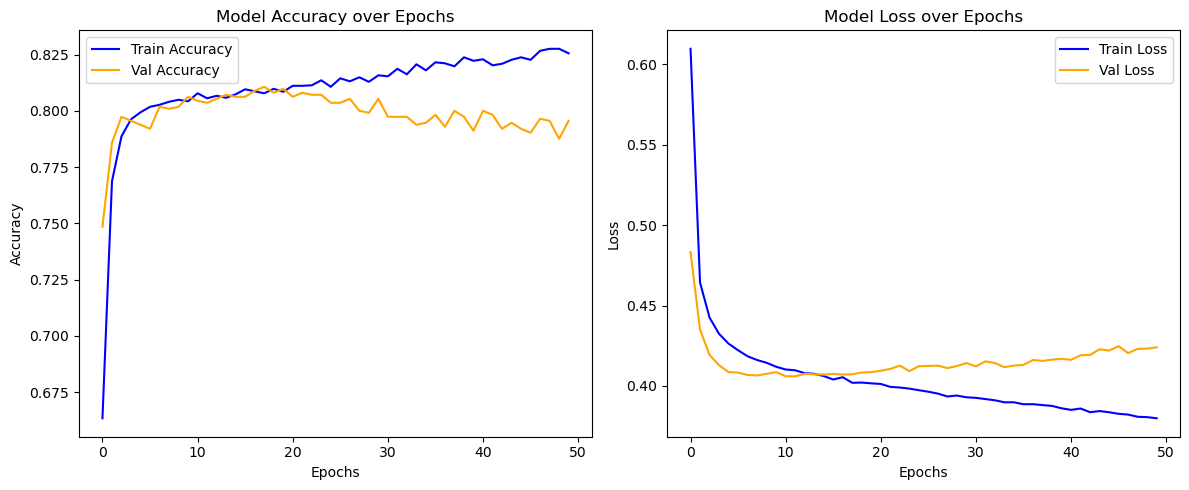

In [58]:


# 1. Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [59]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# new model
optimized_model = Sequential()

# Input Layer + First Hidden Layer
optimized_model.add(Dense(units=16, input_dim=30, activation='relu'))
# 20% Dropout 
optimized_model.add(Dropout(0.2))

# Second Hidden Layer
optimized_model.add(Dense(units=8, activation='relu'))
optimized_model.add(Dropout(0.2))

# Output Layer
optimized_model.add(Dense(units=1, activation='sigmoid'))

# 2. Model Compile 
optimized_model.compile(optimizer='adam', 
                        loss='binary_crossentropy', 
                        metrics=['accuracy'])

# 3. Early Stopping Callback )
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

print("Optimized Model is ready!")

Optimized Model is ready!


In [60]:
history_opt = optimized_model.fit(X_train_scaled, y_train, 
                                  epochs=50, 
                                  batch_size=32, 
                                  validation_split=0.2,
                                  callbacks=[early_stop])

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5647 - loss: 0.8040 - val_accuracy: 0.7440 - val_loss: 0.5177
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7229 - loss: 0.5435 - val_accuracy: 0.7724 - val_loss: 0.4598
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7538 - loss: 0.5005 - val_accuracy: 0.7893 - val_loss: 0.4391
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7744 - loss: 0.4829 - val_accuracy: 0.7973 - val_loss: 0.4289
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7789 - loss: 0.4762 - val_accuracy: 0.7929 - val_loss: 0.4251
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7851 - loss: 0.4579 - val_accuracy: 0.7938 - val_loss: 0.4222
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7889 - loss: 0.4600 - val_accuracy: 0.7964 - val_loss: 0.4216
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7853 - loss: 0.4559 - val_accuracy: 0.

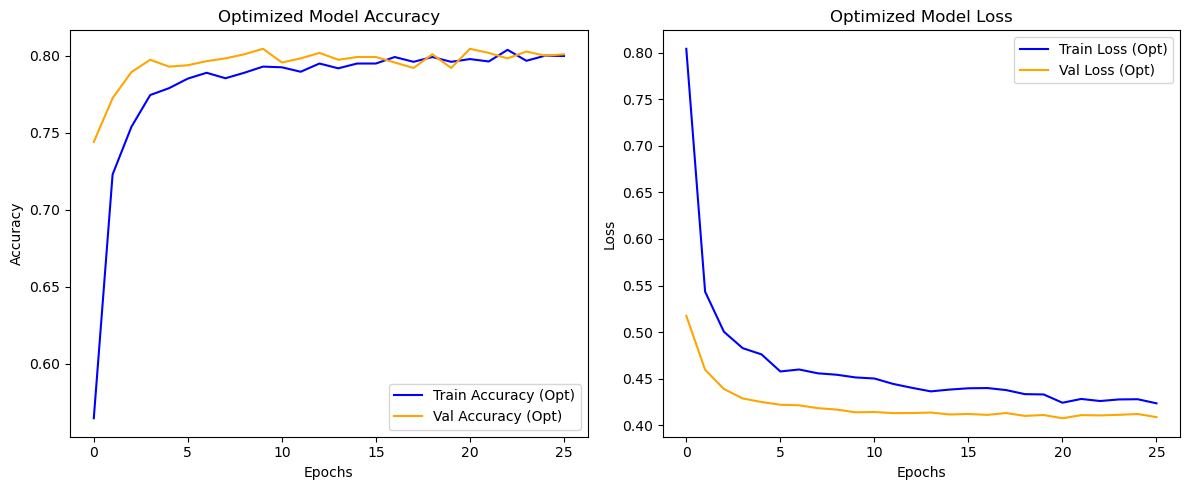

In [61]:

# 1. Accuracy 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_opt.history['accuracy'], label='Train Accuracy (Opt)', color='blue')
plt.plot(history_opt.history['val_accuracy'], label='Val Accuracy (Opt)', color='orange')
plt.title('Optimized Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Loss 
plt.subplot(1, 2, 2)
plt.plot(history_opt.history['loss'], label='Train Loss (Opt)', color='blue')
plt.plot(history_opt.history['val_loss'], label='Val Loss (Opt)', color='orange')
plt.title('Optimized Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

# Build and compile model
imbalance_model = Sequential([
    Dense(units=16, input_dim=30, activation='relu'),
    Dropout(0.2),
    Dense(units=8, activation='relu'),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
])
imbalance_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

C:\Anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
# Train the model
history_imbalance = imbalance_model.fit(
    X_train_scaled, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5798 - loss: 0.6457 - val_accuracy: 0.7138 - val_loss: 0.5880
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6869 - loss: 0.5684 - val_accuracy: 0.7404 - val_loss: 0.5211
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7196 - loss: 0.5374 - val_accuracy: 0.7422 - val_loss: 0.5087
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7284 - loss: 0.5237 - val_accuracy: 0.7449 - val_loss: 0.4993
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7353 - loss: 0.5221 - val_accuracy: 0.7440 - val_loss: 0.5005


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


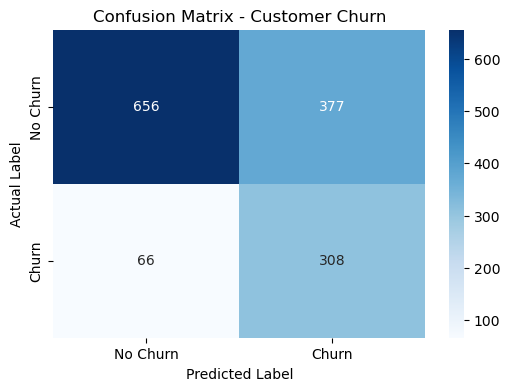


==================== Classification Report ====================
              precision    recall  f1-score   support

    No Churn       0.91      0.64      0.75      1033
       Churn       0.45      0.82      0.58       374

    accuracy                           0.69      1407
   macro avg       0.68      0.73      0.66      1407
weighted avg       0.79      0.69      0.70      1407



In [64]:
# Evaluation, Business Metrics, & Insights

from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions (probabilities) from the trained model
y_pred_prob = imbalance_model.predict(X_test_scaled)

# 2. Convert probabilities to binary outcomes (0 or 1) using a 0.5 threshold
y_pred = (y_pred_prob > 0.5).astype(int)

# 3. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot the confusion matrix using Seaborn Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Customer Churn')
plt.show()

# 5. Print the full classification report
print("\n" + "="*20 + " Classification Report " + "="*20)
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

In [65]:


# 1. Gather all calculated metrics into a structured dictionary
final_comparison_data = {
    'Model': [
        'Logistic Regression (Baseline ML)', 
        'Random Forest (Classical ML)', 
        'Artificial Neural Network (TensorFlow DL)'
    ],
    'Accuracy': [acc_log, acc_rf, 0.7162],
    'Recall (Churn Class)': [rec_log, rec_rf, 0.8075]
}

# 2. Create the Pandas DataFrame
df_model_comparison = pd.DataFrame(final_comparison_data)

# 3. Format and style the output to display as clean percentages
df_model_comparison.style.format({
    'Accuracy': '{:.2%}', 
    'Recall (Churn Class)': '{:.2%}'
}).hide(axis='index')

Model,Accuracy,Recall (Churn Class)
Logistic Regression (Baseline ML),72.64%,79.68%
Random Forest (Classical ML),78.89%,48.66%
Artificial Neural Network (TensorFlow DL),71.62%,80.75%


Author : Isuri Dharmasena